## 1. 서울시 중학교 데이터

### 1) 필요 라이브러리 설치

In [34]:
import pandas as pd
import numpy as np

### 2) 데이터 불러오기

In [35]:
# 서울시 중학교 기본정보(도로명 주소 포함)
df_mid = pd.read_csv('data/서울시 중학교 기본정보.csv', encoding='cp949')

# 서울시 중고등학교 민간개방여부(도로명 주소 미포함)
df_mid_open = pd.read_csv('data/서울특별시교육청_민간개방 학교시설물현황_20250910.csv', encoding='cp949')

In [36]:
df_mid.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
1,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
2,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
3,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
4,중학교,사립,7134141,한양대학교사범대학부속중학교,Hanyang University Middle School,서울특별시성동광진교육지원청,4761,서울특별시 성동구 마조로 42,(사근동/한양사대부속중?고등학교),02-2200-3700,...,일반계,NaN,전기,주간,19600118,19600118,B10,서울특별시교육청,서울특별시,20230615


In [37]:
df_mid.info()

<class 'pandas.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   학교종류명        780 non-null    str    
 1   설립구분         780 non-null    str    
 2   표준학교코드       780 non-null    int64  
 3   학교명          780 non-null    str    
 4   영문학교명        780 non-null    str    
 5   관할조직명        780 non-null    str    
 6   도로명우편번호      780 non-null    int64  
 7   도로명주소        780 non-null    str    
 8   도로명상세주소      780 non-null    str    
 9   전화번호         780 non-null    str    
 10  홈페이지주소       780 non-null    str    
 11  팩스번호         780 non-null    str    
 12  남녀공학구분명      780 non-null    str    
 13  고등학교구분명      0 non-null      float64
 14  산업체특별학급존재여부  780 non-null    str    
 15  고등학교일반실업구분명  768 non-null    str    
 16  특수목적고등학교계열명  0 non-null      float64
 17  입시전후기구분명     780 non-null    str    
 18  주야구분명        780 non-null    str    
 19  설립일자         780 no

In [38]:
# df_mid 중복값 확인
print(df_mid.duplicated().sum())

390


In [39]:
# 중복값 제거
df_mid = df_mid.drop_duplicates(subset=['학교명'])
df_mid.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
2,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
4,중학교,사립,7134141,한양대학교사범대학부속중학교,Hanyang University Middle School,서울특별시성동광진교육지원청,4761,서울특별시 성동구 마조로 42,(사근동/한양사대부속중?고등학교),02-2200-3700,...,일반계,NaN,전기,주간,19600118,19600118,B10,서울특별시교육청,서울특별시,20230615
6,중학교,공립,7134140,자양중학교,Jayang Middle School,서울특별시성동광진교육지원청,5069,서울특별시 광진구 뚝섬로41길 33,(자양동/서울자양중학교),02-446-0365,...,일반계,NaN,전기,주간,19840301,19840301,B10,서울특별시교육청,서울특별시,20230615
8,중학교,공립,7134139,용곡중학교,Yong-gok Middle School,서울특별시성동광진교육지원청,4940,서울특별시 광진구 용마산로22길 76,(중곡동/용곡중학교),02-452-2622,...,일반계,NaN,전기,주간,19821209,19830504,B10,서울특별시교육청,서울특별시,20230615


In [40]:
# 학교 종류명, 설립구분, 학교명, 관할조직명, 도로명주소만 남기기
df_mid = df_mid[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소']]
df_mid.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47
2,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189
4,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42
6,중학교,공립,자양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로41길 33
8,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76


In [41]:
df_mid_open.head()

,시도교육청,교육지원청,지역,학교명,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부
0,서울특별시교육청,서울특별시교육청,송파구,가락고등학교,고,무,시설없음,무,시설없음,시설없음,시설없음,시설없음
1,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가락중학교,중,유,시설없음,무,유,시설없음,시설없음,시설없음
2,서울특별시교육청,서울특별시남부교육지원청,금천구,가산중학교,중,무,시설없음,유,시설없음,시설없음,시설없음,유
3,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가원중학교,중,유,시설없음,시설없음,시설없음,시설없음,시설없음,시설없음
4,서울특별시교육청,서울특별시교육청,서대문구,가재울고등학교,고,무,시설없음,시설없음,유,시설없음,시설없음,시설없음


In [50]:
# 중학교만 필터링
df_mid_open = df_mid_open[df_mid_open['학교급코드'] == '중']
df_mid_open.info()

<class 'pandas.DataFrame'>
Index: 279 entries, 1 to 980
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   시도교육청       279 non-null    str  
 1   교육지원청       279 non-null    str  
 2   지역          279 non-null    str  
 3   학교명         279 non-null    str  
 4   학교급코드       279 non-null    str  
 5   교실 개방여부     279 non-null    str  
 6   시청각실 개방여부   279 non-null    str  
 7   체육관 개방여부    279 non-null    str  
 8   운동장 개방여부    279 non-null    str  
 9   수영장 개방여부    279 non-null    str  
 10  테니스장 개방여부   279 non-null    str  
 11  잔디운동장 개방여부  279 non-null    str  
dtypes: str(12)
memory usage: 28.3 KB


In [42]:
# df_mid_open 결측치 확인
print(df_mid_open.isnull().sum())

시도교육청         0
교육지원청         0
지역            0
학교명           0
학교급코드         0
교실 개방여부       0
시청각실 개방여부     0
체육관 개방여부      0
운동장 개방여부      0
수영장 개방여부      0
테니스장 개방여부     0
잔디운동장 개방여부    0
dtype: int64


In [43]:
# df_mid_open 중복값 확인
print(df_mid_open.duplicated().sum())

0


### 3) df_mid와 df_mid_open의 차집합 구하기 
→ df_mid_open에 있는데, df_mid에 없는 학교는 금호여자중학교 뿐: 2024년부터 휴업하여 2026년부터 '금호중학교'로 교명을 바꾸어 재개교한 학교임

In [44]:
# df_mid와 df_mid_open의 차집합 구하기
# df_mid의 학교명과 df_mid_open의 학교명을 비교하여 df_mid에만 있는 학교명 추출
mid_only = df_mid[~df_mid['학교명'].isin(df_mid_open['학교명'])]
# mid_only의 학교명 출력
print(mid_only['학교명'])
# df_mid와 df_mid_open의 교집합 구하기
mid_intersection = df_mid[df_mid['학교명'].isin(df_mid_open['학교명'])]
# mid_intersection의 학교명 출력
print(mid_intersection['학교명'])
# df_mid_open에만 있는 학교명 추출
open_only = df_mid_open[~df_mid_open['학교명'].isin(df_mid['학교명'])]
# open_only의 학교명 출력
print(open_only['학교명'])
# open_only의 '학교명'에 중학교가 포함되어 있는지 확인
open_only_mid = open_only[open_only['학교명'].str.contains('중학교')]
# open_only_mid의 학교 개수 출력
print(open_only_mid['학교명'])

0      동국대학교사범대학부속가람중학교
4        한양대학교사범대학부속중학교
24              대원국제중학교
44       건국대학교사범대학부속중학교
46       중앙대학교사범대학부속중학교
             ...       
754             영란여자중학교
772      동국대학교사범대학부속중학교
774               대광중학교
776               경희중학교
778             경희여자중학교
Name: 학교명, Length: 112, dtype: str
2       행당중학교
6       자양중학교
8       용곡중학교
10      옥정중학교
12      양진중학교
        ...  
762     상봉중학교
764     봉화중학교
766     면목중학교
768     동원중학교
770    동대문중학교
Name: 학교명, Length: 278, dtype: str
0         가락고등학교
4        가재울고등학교
12        강일고등학교
19        개포고등학교
22        경기고등학교
         ...    
965    한강미디어고등학교
968     한성과학고등학교
974     혜화여자고등학교
978       효문고등학교
981       휘봉고등학교
Name: 학교명, Length: 704, dtype: str
66    금호여자중학교
Name: 학교명, dtype: str


df_mid에는 '금호중학교'로, df_mid_open에는 '금호여자중학교'로 등록되어 있음을 확인
 → '금호여자중학교'로 통일

In [45]:
# df_mid에서 '금호중학교' 있는지 확인
print(df_mid[df_mid['학교명'] == '금호중학교'])
# df_mid_open에서 '금호중학교' 있는지 확인
print(df_mid_open[df_mid_open['학교명'] == '금호중학교'])

    학교종류명 설립구분    학교명         관할조직명           도로명주소
430   중학교   공립  금호중학교  서울특별시중부교육지원청  서울특별시 중구 청구로 6
Empty DataFrame
Columns: [시도교육청, 교육지원청, 지역, 학교명, 학교급코드, 교실 개방여부, 시청각실 개방여부, 체육관 개방여부, 운동장 개방여부, 수영장 개방여부, 테니스장 개방여부, 잔디운동장 개방여부]
Index: []


In [46]:
# df_mid_open에서 '금호여자중학교' → '금호중학교'로 변경
df_mid_open['학교명'] = df_mid_open['학교명'].replace('금호여자중학교', '금호중학교')

### 4) df_mid와 df_mid_open에 모두 들어있는 학교를 기준으로 필터링

In [51]:
# 학교명 기준으로 병합
df_merged = pd.merge(df_mid, df_mid_open, on='학교명', how='inner', suffixes=('_기본정보', '_민간개방'))

In [52]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   학교종류명       279 non-null    str  
 1   설립구분        279 non-null    str  
 2   학교명         279 non-null    str  
 3   관할조직명       279 non-null    str  
 4   도로명주소       279 non-null    str  
 5   시도교육청       279 non-null    str  
 6   교육지원청       279 non-null    str  
 7   지역          279 non-null    str  
 8   학교급코드       279 non-null    str  
 9   교실 개방여부     279 non-null    str  
 10  시청각실 개방여부   279 non-null    str  
 11  체육관 개방여부    279 non-null    str  
 12  운동장 개방여부    279 non-null    str  
 13  수영장 개방여부    279 non-null    str  
 14  테니스장 개방여부   279 non-null    str  
 15  잔디운동장 개방여부  279 non-null    str  
dtypes: str(16)
memory usage: 35.0 KB


In [53]:
df_merged.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,시도교육청,교육지원청,지역,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,서울특별시교육청,서울특별시성동광진교육지원청,성동구,중,유,시설없음,무,유,시설없음,시설없음,시설없음
1,중학교,공립,자양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로41길 33,서울특별시교육청,서울특별시성동광진교육지원청,광진구,중,무,시설없음,무,시설없음,시설없음,시설없음,무
2,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,서울특별시교육청,서울특별시성동광진교육지원청,광진구,중,무,무,무,시설없음,시설없음,시설없음,유
3,중학교,공립,옥정중학교,서울특별시성동광진교육지원청,서울특별시 성동구 한림말길 11,서울특별시교육청,서울특별시성동광진교육지원청,성동구,중,유,유,무,무,시설없음,시설없음,시설없음
4,중학교,공립,양진중학교,서울특별시성동광진교육지원청,서울특별시 광진구 워커힐로 32,서울특별시교육청,서울특별시성동광진교육지원청,광진구,중,유,시설없음,유,시설없음,시설없음,시설없음,시설없음


In [55]:
# 운동장 개방 여부 또는 잔디운동장 개방 여부 = '유'인 학교 필터링
df_merged_open = df_merged[(df_merged['운동장 개방여부'] == '유') | (df_merged['잔디운동장 개방여부'] == '유')]
df_merged_open.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,시도교육청,교육지원청,지역,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,서울특별시교육청,서울특별시성동광진교육지원청,성동구,중,유,시설없음,무,유,시설없음,시설없음,시설없음
2,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,서울특별시교육청,서울특별시성동광진교육지원청,광진구,중,무,무,무,시설없음,시설없음,시설없음,유
5,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,서울특별시교육청,서울특별시성동광진교육지원청,광진구,중,시설없음,시설없음,시설없음,유,시설없음,시설없음,시설없음
6,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,서울특별시교육청,서울특별시성동광진교육지원청,성동구,중,시설없음,시설없음,무,유,시설없음,시설없음,시설없음
8,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,서울특별시교육청,서울특별시성동광진교육지원청,성동구,중,유,시설없음,유,유,시설없음,시설없음,시설없음


In [56]:
df_merged_open.info()

<class 'pandas.DataFrame'>
Index: 173 entries, 0 to 277
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   학교종류명       173 non-null    str  
 1   설립구분        173 non-null    str  
 2   학교명         173 non-null    str  
 3   관할조직명       173 non-null    str  
 4   도로명주소       173 non-null    str  
 5   시도교육청       173 non-null    str  
 6   교육지원청       173 non-null    str  
 7   지역          173 non-null    str  
 8   학교급코드       173 non-null    str  
 9   교실 개방여부     173 non-null    str  
 10  시청각실 개방여부   173 non-null    str  
 11  체육관 개방여부    173 non-null    str  
 12  운동장 개방여부    173 non-null    str  
 13  수영장 개방여부    173 non-null    str  
 14  테니스장 개방여부   173 non-null    str  
 15  잔디운동장 개방여부  173 non-null    str  
dtypes: str(16)
memory usage: 23.0 KB


In [57]:
# 학교종류명, 설립구분, 학교명, 관할조직명, 도로명주소, 지역, 운동장 개방 여부, 잔디운동장 개방 여부만 남기기
df_merged_open = df_merged_open[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소', '지역', '운동장 개방여부', '잔디운동장 개방여부']]
df_merged_open.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,지역,운동장 개방여부,잔디운동장 개방여부
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,성동구,유,시설없음
2,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,광진구,시설없음,유
5,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,광진구,유,시설없음
6,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,성동구,유,시설없음
8,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,성동구,유,시설없음


In [63]:
# df_merged_open to csv
df_merged_open.to_csv('data/서울시 중학교 민간개방 운동장 정보.csv', index=False, encoding='cp949')

In [58]:
# 각 지역별로 몇 개의 학교가 있는지 확인
school_counts = df_merged_open['지역'].value_counts()
print(school_counts)

지역
노원구     18
강남구     12
강서구     12
송파구     10
양천구     10
구로구     10
중랑구     10
관악구      9
성북구      9
광진구      6
동작구      6
강동구      6
강북구      6
도봉구      6
영등포구     6
서초구      5
금천구      5
은평구      5
동대문구     5
서대문구     4
마포구      4
성동구      3
용산구      3
중구       2
종로구      1
Name: count, dtype: int64


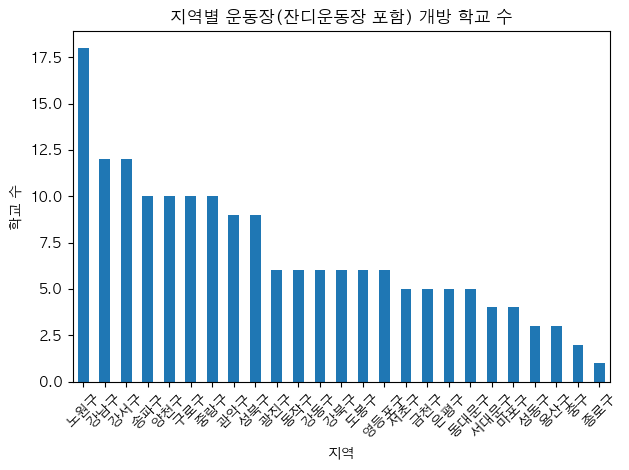

In [62]:
# 시각화
import matplotlib.pyplot as plt
# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'  # MacOS
# 지역별 학교 개수 시각화
school_counts.plot(kind='bar')
plt.title('지역별 운동장(잔디운동장 포함) 개방 학교 수')
plt.xlabel('지역')
plt.ylabel('학교 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5) 좌표(위경도) 포함한 데이터셋 반환

In [65]:
df_with_coordinates = pd.read_csv('data/운동장 민간개방 중학교_위도 경도 변환.csv')
df_with_coordinates.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,Latitude,Longitude,지역,운동장 개방여부,잔디운동장 개방여부
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,성동구,유,시설없음
1,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,37.565795,127.088826,광진구,시설없음,유
2,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,광진구,유,시설없음
3,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,성동구,유,시설없음
4,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,성동구,유,시설없음


In [67]:
# 시각화
import folium
# 서울시 중심 좌표
seoul_center = [37.5665, 126.9780]
# 지도 생성
m = folium.Map(location=seoul_center, zoom_start=11)
# 학교 위치에 마커 추가
for idx, row in df_with_coordinates.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['학교명']
    ).add_to(m)
# 지도 저장
m.save('data/서울시 중학교 민간개방 운동장 위치 지도.html')

In [68]:
# 지도 보기
m

### 6) 체육장 용지 면적이 나와있는 데이터

In [71]:
df_size = pd.read_csv('data/2025년도_학교용지 현황(중)_서울특별시교육청.csv')
df_size.head()

,시도교육청,교육지원청,지역,정보공시 학교코드,학교명,학교급코드,설립구분,제외여부,제외사유,교사대지,체육장,계,부속토지,합 계,공동사용여부,공동사용학교명,설립유형
0,서울특별시교육청,서울특별시강서양천교육지원청,서울특별시 강서구,S010000975,등촌중학교,3,사립,N,NaN,2137,6360,8497,38887,47384,×,NaN,단설
1,서울특별시교육청,서울특별시서부교육지원청,서울특별시 은평구,S010001951,영락중학교,3,사립,N,NaN,2112,4983,7095,13148,20243,×,NaN,단설
2,서울특별시교육청,서울특별시동부교육지원청,서울특별시 중랑구,S010001387,중화중학교,3,공립,N,NaN,3744,3916,7660,9615,17275,×,NaN,단설
3,서울특별시교육청,서울특별시강동송파교육지원청,서울특별시 강동구,S010000891,천호중학교,3,공립,N,NaN,4387,4050,8437,7987,16424,×,NaN,단설
4,서울특별시교육청,서울특별시동작관악교육지원청,서울특별시 동작구,S010001546,강현중학교,3,공립,N,NaN,2985,4129,7114,7767,14881,×,NaN,단설


In [72]:
# '시도교육청', '교육지원청', '지역', '학교명', '설립구분', '체육장', '공동사용여부', '공동사용학교명' 컬럼만 남기기
df_size = df_size[['시도교육청', '교육지원청', '지역', '학교명', '설립구분', '체육장', '공동사용여부', '공동사용학교명']]
df_size.head()

,시도교육청,교육지원청,지역,학교명,설립구분,체육장,공동사용여부,공동사용학교명
0,서울특별시교육청,서울특별시강서양천교육지원청,서울특별시 강서구,등촌중학교,사립,6360,×,NaN
1,서울특별시교육청,서울특별시서부교육지원청,서울특별시 은평구,영락중학교,사립,4983,×,NaN
2,서울특별시교육청,서울특별시동부교육지원청,서울특별시 중랑구,중화중학교,공립,3916,×,NaN
3,서울특별시교육청,서울특별시강동송파교육지원청,서울특별시 강동구,천호중학교,공립,4050,×,NaN
4,서울특별시교육청,서울특별시동작관악교육지원청,서울특별시 동작구,강현중학교,공립,4129,×,NaN


In [78]:
# df_with_coordinates와 df_size를 학교명 기준으로 병합
# 겹치는 컬럼은 설립구분, 지역이므로 왼쪽으로 병합
df_final = pd.merge(df_with_coordinates, df_size, on='학교명', how='left', suffixes=('_x', '_y'))
df_final.info()
df_final.head()


<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   학교종류명       173 non-null    str    
 1   설립구분_x      173 non-null    str    
 2   학교명         173 non-null    str    
 3   관할조직명       173 non-null    str    
 4   도로명주소       173 non-null    str    
 5   Latitude    173 non-null    float64
 6   Longitude   173 non-null    float64
 7   지역_x        173 non-null    str    
 8   운동장 개방여부    173 non-null    str    
 9   잔디운동장 개방여부  173 non-null    str    
 10  시도교육청       172 non-null    str    
 11  교육지원청       172 non-null    str    
 12  지역_y        172 non-null    str    
 13  설립구분_y      172 non-null    str    
 14  체육장         172 non-null    float64
 15  공동사용여부      172 non-null    str    
 16  공동사용학교명     6 non-null      str    
dtypes: float64(3), str(14)
memory usage: 23.1 KB


,학교종류명,설립구분_x,학교명,관할조직명,도로명주소,Latitude,Longitude,지역_x,운동장 개방여부,잔디운동장 개방여부,시도교육청,교육지원청,지역_y,설립구분_y,체육장,공동사용여부,공동사용학교명
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,6117.0,×,NaN
1,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,37.565795,127.088826,광진구,시설없음,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,5025.0,×,NaN
2,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,광진구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,7240.0,×,NaN
3,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,7004.0,×,NaN
4,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,0.0,○,무학여자고등학교


In [85]:
# 체육장이 0인 학교 필터링
df_final_no_gym = df_final[df_final['체육장'] == 0]\
# 체육장이 0인 학교 개수 확인
no_gym_count = df_final_no_gym.shape[0]
print(f"체육장이 0인 학교 수: {no_gym_count}")
# 이름 확인
print(df_final_no_gym['학교명'])

# 해당 학교의 공동사용 학교 확인
for idx, row in df_final_no_gym.iterrows():
    print(f"학교명: {row['학교명']}, 공동사용여부: {row['공동사용여부']}, 공동사용학교명: {row['공동사용학교명']}")



체육장이 0인 학교 수: 4
4      무학중학교
10    영등포중학교
41     길음중학교
95     청운중학교
Name: 학교명, dtype: str
학교명: 무학중학교, 공동사용여부: ○, 공동사용학교명: 무학여자고등학교
학교명: 영등포중학교, 공동사용여부: ○, 공동사용학교명: 영등포고등학교
학교명: 길음중학교, 공동사용여부: ○, 공동사용학교명: 서울길음초등학교
학교명: 청운중학교, 공동사용여부: ○, 공동사용학교명: 경기상업고등학교


In [90]:
# 체육장이 0인 학교의 실제 체육장 크기를 확인하기 위해 고등학교 정보 불러오기
df_high_size = pd.read_csv('data/2025년도_학교용지 현황(고)_서울특별시교육청.csv')
df_high_size.head()
# '무학여자고등학교', '영등포고등학교', '서울길음초등학교', '경기상업고등학교'의 체육장 크기 확인하여 체육장이 0인 학교의 실제 체육장 크기 추정
schools_to_check = ['무학여자고등학교', '영등포고등학교', '서울길음초등학교', '경기상업고등학교']
for school in schools_to_check:
    gym_size = df_high_size[df_high_size['학교명'] == school]['체육장'].values
    if len(gym_size) > 0:
        print(f"{school}의 체육장 크기: {gym_size[0]}")

# 해당 값을 df_final의 체육장 크기로 대체
# 무학여자고등학교 체육장 크기로 대체
df_final.loc[df_final['학교명'] == '무학중학교', '체육장'] = df_high_size[df_high_size['학교명'] == '무학여자고등학교']['체육장'].values[0]
# 영등포고등학교 체육장 크기로 대체
df_final.loc[df_final['학교명'] == '영등포중학교', '체육장'] = df_high_size[df_high_size['학교명'] == '영등포고등학교']['체육장'].values[0]
# 경기상업고등학교 체육장 크기로 대체
df_final.loc[df_final['학교명'] == '청운중학교', '체육장'] = df_high_size[df_high_size['학교명'] == '경기상업고등학교']['체육장'].values[0]
# 체육장이 0인 학교 개수 다시 확인
no_gym_count_updated = df_final[df_final['체육장'] == 0].shape[0]
print(f"체육장이 0인 학교 수 (업데이트 후): {no_gym_count_updated}")

# 초등학교 정보 불러오기
df_elementary_size = pd.read_csv('data/2025년도_학교용지 현황(초)_서울특별시교육청.csv')
df_elementary_size.head()
# 서울길음초등학교 체육장 크기로 대체
df_final.loc[df_final['학교명'] == '길음중학교', '체육장'] = df_elementary_size[df_elementary_size['학교명'] == '서울길음초등학교']['체육장'].values[0]
# 체육장이 0인 학교 개수 다시 확인
no_gym_count_final = df_final[df_final['체육장'] == 0].shape[0]
print(f"체육장이 0인 학교 수 (최종 업데이트 후): {no_gym_count_final}")
# 체육장이 0인 학교의 공동사용 학교명 확인
for idx, row in df_final[df_final['체육장'] == 0].iterrows():
    print(f"학교명: {row['학교명']}, 공동사용여부: {row['공동사용여부']}, 공동사용학교명: {row['공동사용학교명']}")



무학여자고등학교의 체육장 크기: 11290
영등포고등학교의 체육장 크기: 7725
경기상업고등학교의 체육장 크기: 11542
체육장이 0인 학교 수 (업데이트 후): 0
체육장이 0인 학교 수 (최종 업데이트 후): 0


In [92]:
# 지역_y, 설립구분_y 삭제
df_final = df_final.drop(columns=['지역_y', '설립구분_y'])

# 지역_x → 지역, 설립구분_x → 설립구분으로 컬럼명 변경
df_final = df_final.rename(columns={'지역_x': '지역', '설립구분_x': '설립구분'})

In [93]:
# csv 파일로 저장
df_final.to_csv('data/서울시 중학교 민간개방 운동장 정보_체육장 크기 업데이트.csv', index=False, encoding='cp949')
df_final.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,Latitude,Longitude,지역,운동장 개방여부,잔디운동장 개방여부,시도교육청,교육지원청,체육장,공동사용여부,공동사용학교명
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,6117.0,×,NaN
1,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76,37.565795,127.088826,광진구,시설없음,유,서울특별시교육청,서울특별시성동광진교육지원청,5025.0,×,NaN
2,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,광진구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,7240.0,×,NaN
3,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,7004.0,×,NaN
4,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,성동구,유,시설없음,서울특별시교육청,서울특별시성동광진교육지원청,11290.0,○,무학여자고등학교
